# Estimar porcentaje de area con potencial de minería de oro en cada municipio

## Objetivo
Quiero calcular el area y el porcentaje de area de cada municipio que está dentro de los polígonos de potencial de minerales y metales preciosos

## Datos
- Polígonos de areas con potencial de oro del SGC _./Data/2_SGC_Zonas_Potenciales_Metales_Minerales_Preciosos_
- Polígonos del _./Data/3_DANE_Departamentos_Municipios_

# Importar paquetes

In [1]:
# Manejo de datos
import geopandas as gpd # Manejo de datos geoespaciales
import pandas as pd # Manejo de datos generales

# Cálculo numérico
import numpy as np

# Gráficas
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# Cargar datos

In [2]:
# Rutas de los archivos
ruta_potencial = '../../Data/2_SGC_Zonas_Potenciales_Metales_Minerales_Preciosos/75f31543-bd1b-43bc-942f-99932ea7eba92020412-1-1srbe6r.4f47.shp'
ruta_municipios = '../../Data/3_DANE_Departamentos_Municipios/ADMINISTRATIVO/MGN_ADM_MPIO_GRAFICO.shp'
ruta_departamentos = '../../Data/3_DANE_Departamentos_Municipios/ADMINISTRATIVO/MGN_ADM_DPTO_POLITICO.shp'

In [3]:
# Cargar archivos
gdf_potencial = gpd.read_file(ruta_potencial)
gdf_municipios = gpd.read_file(ruta_municipios)
gdf_departamentos = gpd.read_file(ruta_departamentos)

In [4]:
# Explorar datos
display(gdf_potencial.head(2))
display(gdf_municipios.head(2))

,FID,OBJECTID,IDZPI,NOMBRE,GR_MINERAL,SUBGRUPO_M,ELEM_PRINC,ANOMALIAS,DESC_TEMAT,DESC_GEOGR,...,CAL_ANOM,CAL_FGRA,CAL_FMAG,SUM_POND,CALIFICA,SHAPE_AREA,SHAPE_LEN,Shape__Are,Shape__Len,geometry
0,1,1,P110_01,Vetas 1,METALES Y MINERALES PRECIOSOS,MINERALES DEL ORO,"Au, Ag","Vetas y California, Macizo de Santander 1, Mac...","MINERALIZACION, MINERALES PRECIOSOS, DISTRITO,...","SURATA, CORDILLERA ORIENTAL, SANTANDER, PARAMO...",...,3,0,3,22.00,2.70,0.198794,2.31958,2.483724e+09,259905.908661,"POLYGON ((-8119115.336 839477.764, -8118849.05..."
1,2,2,P114_01,Dabeiba 1,METALES Y MINERALES PRECIOSOS,MINERALES DEL ORO,"Zn, Au-Ag",Dabeiba-Monos,"ORO, PLATA, METALES PRECIOSOS","ENCALICHADA, MONOS, DABEIBA, RIO URAMITA, FILO...",...,1,0,-1,1.24,0.85,0.008625,0.34832,1.076837e+08,38940.994084,"POLYGON ((-8476228.613 779193.446, -8476124.77..."


,dpto_ccdgo,mpio_ccdgo,mpio_cdpmp,dpto_cnmbr,mpio_cnmbr,mpio_crslc,mpio_tipo,mpio_narea,mpio_nano,shape_Leng,shape_Area,geometry
0,05,001,05001,ANTIOQUIA,MEDELLÍN,1965,MUNICIPIO,374.741484,2025,1.035380,0.030608,"POLYGON ((-75.4857 6.20163, -75.48567 6.20148,..."
1,05,002,05002,ANTIOQUIA,ABEJORRAL,1814,MUNICIPIO,506.959782,2024,1.158504,0.041384,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571..."


In [9]:
# Mostrar información de los datos disponibles
print("\n"+"***"*20+"Zonas metales preciosos")
display(gdf_potencial.info())

print("\n"+"***"*20+"Municipios")
display(gdf_municipios.info())


************************************************************Zonas metales preciosos
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID         115 non-null    int32   
 1   OBJECTID    115 non-null    int32   
 2   IDZPI       115 non-null    object  
 3   NOMBRE      115 non-null    object  
 4   GR_MINERAL  115 non-null    object  
 5   SUBGRUPO_M  115 non-null    object  
 6   ELEM_PRINC  115 non-null    object  
 7   ANOMALIAS   98 non-null     object  
 8   DESC_TEMAT  98 non-null     object  
 9   DESC_GEOGR  98 non-null     object  
 10  NUM_ANOM    115 non-null    object  
 11  POTENCIAL   115 non-null    object  
 12  T_MINERIA   86 non-null     object  
 13  RESTRICCIO  90 non-null     object  
 14  RAN_GRAV    115 non-null    object  
 15  RAN_MAGN    72 non-null     object  
 16  CAL_ANOM    115 non-null    int32   
 17 

None


************************************************************Municipios
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   dpto_ccdgo  1122 non-null   object  
 1   mpio_ccdgo  1122 non-null   object  
 2   mpio_cdpmp  1122 non-null   object  
 3   dpto_cnmbr  1122 non-null   object  
 4   mpio_cnmbr  1122 non-null   object  
 5   mpio_crslc  1122 non-null   object  
 6   mpio_tipo   1122 non-null   object  
 7   mpio_narea  1122 non-null   float64 
 8   mpio_nano   1122 non-null   int32   
 9   shape_Leng  1122 non-null   float64 
 10  shape_Area  1122 non-null   float64 
 11  geometry    1122 non-null   geometry
dtypes: float64(3), geometry(1), int32(1), object(7)
memory usage: 100.9+ KB


None

# Pre-Procesamiento

## Asegurarse que las capas estén en el mismo Sistema de Coordenadas
Para que el cálculo de áreas tenga sentido, ambas capas deben estar en un sistema de coordenadas apropiado para medir areas en Colombia.

Se va a usar MAGNA-SIRGAS (EPSG:3116), que es el sistema geodésico oficial de Colombia.
- Lo usa el Instituto Geográfico Agustín Codazzi (IGAC)
- Es el estándar en cartografía oficial del país

In [5]:
# Explorar Coordinate Reference System (CRS)
print('*'*20 + '\nCRS Original')
print('Potencial:', gdf_potencial.crs)
print('Municipios:', gdf_municipios.crs)
print('Departamentos:', gdf_departamentos.crs)

# Reproyectar ambas capas a un CRS apropiado para Colombia
# Se va a proyectar en MAGNA-SIRGAS que es el estándar en Colombia
crs_area = "EPSG:3116"
gdf_potencial = gdf_potencial.to_crs(crs_area)
gdf_municipios = gdf_municipios.to_crs(crs_area)
gdf_departamentos = gdf_departamentos.to_crs(crs_area)

# Mostrar nuevos sistema de coordenadas
print('*'*20 + '\nNuevo CRS')
print('Potencial:', gdf_potencial.crs)
print('Municipios:', gdf_municipios.crs)
print('Departamentos:', gdf_departamentos.crs)

********************
CRS Original
Potencial: EPSG:3857
Municipios: EPSG:4326
Departamentos: EPSG:4326
********************
Nuevo CRS
Potencial: EPSG:3116
Municipios: EPSG:3116
Departamentos: EPSG:3116


## Revisar geometrías invalidas

In [6]:
print('*'*20 + '\nPotencial')
print(f"\nVálidas:\n{gdf_potencial.is_valid.value_counts()}")
print(f"\nVacías: {gdf_potencial.is_empty.sum()}")
print(f"Totales: {gdf_potencial.shape[0]}")

print('\n'+'*'*20 + '\nMunicipios')
print(f"\nVálidas:\n{gdf_municipios.is_valid.value_counts()}")
print(f"\nVacías: {gdf_municipios.is_empty.sum()}")
print(f"Totales: {gdf_municipios.shape[0]}")

print('\n'+'*'*20 + '\nDepartamentos')
print(f"\nVálidas:\n{gdf_departamentos.is_valid.value_counts()}")
print(f"\nVacías: {gdf_departamentos.is_empty.sum()}")
print(f"Totales: {gdf_departamentos.shape[0]}")

********************
Potencial

Válidas:
True    115
Name: count, dtype: int64

Vacías: 0
Totales: 115

********************
Municipios

Válidas:
True    1122
Name: count, dtype: int64

Vacías: 0
Totales: 1122

********************
Departamentos

Válidas:
True    33
Name: count, dtype: int64

Vacías: 0
Totales: 33


## Organizar categorías de minerales

In [7]:
# Los subgrupos y minerales de cada polígono no están completamente ordenados
display(gdf_potencial['ELEM_PRINC'].unique())
display(gdf_potencial['SUBGRUPO_M'].unique())

array(['Au, Ag', 'Zn, Au-Ag', 'Au-Ag', 'Au', 'Au-MGP', 'Au, Cu, Ag',
       'MGP', 'Au-Cu, Au, Cr-Ni, Ag', 'Cr, Pb-Zn, Au, Au-Ag',
       'Be, Na/K, Li/Na, Na, K, Li, Pb, K/Na', 'Na/K', 'Au, Au-Ag, Ag',
       'Au, Cu', 'Na/K, Li/Na, Na, K, Li, Na/Li, Ba',
       'Zn, Ag, Au-Ag, Sr, Mo, Pb, Au, Sb, Cu, Ba', 'Au, Ag-Au, Ag',
       'Au-Ag, Ag', 'Pb, Zn, Au, Cu', 'As, Au, Au-Ag',
       'Pb, Zn, Au, Au-Ag', 'As, Au-Ag', 'Qz, Au',
       'Au-MGP, Au, Ag, MPG-Au', 'Pb, Au, Ag', 'Au-MGP, Au, Au-Ag, MGP',
       'Ag', 'As, Au, Au-Ag, Ag', 'Cr-Ni, Au-Ag', 'Au, Au-Ag',
       'Cu, Au, Au-Ag, Ag', 'Pt, Au, Au-Ag, Ag', 'Au-MGP, Au',
       'Au-MGP, Au, Ag', 'MGP-Au, Au-MGP', 'Au-Cu, Au-Ag, Ag',
       'Sb, Au-Cu, Au, Au-Ag', 'Au, Pt, Au-Ag', 'Na/Li'], dtype=object)

array(['MINERALES DEL ORO', 'MINERALES DEL PLATINO',
       'MINERALES DE PLATA, MINERALES DEL ORO', 'MINERALES PRECIOSOS',
       'MINERALES DELORO, MINERALES DEL ORO', 'MIENRALES DEL ORO',
       'MINERALES PRECIOSOS, MINERALES DELORO, MINERALES DEL ORO',
       'MINERALES DEL PLATINO, MINERALES DEL ORO', 'MINERALES DE PLATA'],
      dtype=object)

In [8]:
def clasificar_mineral(elem):
    """
    Clasifica ELEM_PRINC en categorías geológico-económicas amplias.
    """
    if pd.isna(elem):
        return "Otros"
    
    s = str(elem).upper().strip()
    
    # Normalizar separadores
    s = s.replace("/", "-").replace(",", "-")
    partes = [x.strip() for x in s.split("-") if x.strip() != ""]
    partes_set = set(partes)
    
    # Tokens relevantes
    tiene_au = "AU" in partes_set
    tiene_ag = "AG" in partes_set
    tiene_cu = "CU" in partes_set
    tiene_pb = "PB" in partes_set
    tiene_zn = "ZN" in partes_set
    tiene_mgp = "MGP" in partes_set
    tiene_pt = "PT" in partes_set
    
    # Platinoides
    if tiene_mgp or tiene_pt:
        return "Platinoides"
    
    # Metales base
    n_base = sum([tiene_cu, tiene_pb, tiene_zn])
    
    # Preciosos
    n_preciosos = sum([tiene_au, tiene_ag])
    
    # Polimetálicos / complejos:
    # mezcla de preciosos con base metals, o combinaciones largas
    if (n_preciosos >= 1 and n_base >= 1) or len(partes_set) >= 4:
        return "Polimetálicos / complejos"
    
    # Metales base
    if n_base >= 1:
        return "Metales base"
    
    # Oro y preciosos
    if tiene_au or tiene_ag:
        return "Oro y preciosos"
    
    return "Otros"

In [9]:
# Aplicar la clasificación
gdf_potencial["categoria_mineral"] = gdf_potencial["ELEM_PRINC"].apply(clasificar_mineral)

print("Categorías minerales asignadas\n")
display(gdf_potencial["categoria_mineral"].value_counts(dropna=False))

Categorías minerales asignadas



categoria_mineral
Oro y preciosos              81
Polimetálicos / complejos    16
Platinoides                  16
Otros                         2
Name: count, dtype: int64

# Procesamiento

## Intersección de polígonos

In [10]:
# Extraer información de interés
municipios_base = gdf_municipios[['mpio_cdpmp', 'mpio_cnmbr', 'geometry']]
potencial_base = gdf_potencial.copy()

# Hcaer intersección de polígonos
gdf_interseccion = gpd.overlay(potencial_base, municipios_base, how='intersection')

# Explorar el resultado
print('\n'+'*'*20 + '\nShape: ', gdf_interseccion.shape)
print('\n'+'*'*20 +'\nData:')
print(gdf_interseccion.head())
print('\n'+'*'*20 +'\n\nColumnas:')
print(gdf_interseccion.columns)
print('\n'+'*'*20 +'\n\nCada polígono de pontencial pudo quedar dividido en varios municipios:')
display(gdf_interseccion.groupby('FID')['mpio_cnmbr'].count().sort_values(ascending=False))

# Calcular area de cada polígono
# Como ya estoy en Bogotá-Magnas-Sirgas, los cálculos de area ya salen en m^2
gdf_interseccion["area_intersectada_m2"] = gdf_interseccion.geometry.area

# Calcular el area de cada municipio
municipios_base["area_municipio_m2"] = municipios_base.geometry.area

# Agregar cálculo de area a gdf de intersección
gdf_interseccion = gdf_interseccion.merge(
    municipios_base[["mpio_cdpmp", "area_municipio_m2"]],
    on="mpio_cdpmp",
    how="left"
)




********************
Shape:  (645, 29)

********************
Data:
   FID  OBJECTID    IDZPI   NOMBRE                     GR_MINERAL  \
0    1         1  P110_01  Vetas 1  METALES Y MINERALES PRECIOSOS   
1    1         1  P110_01  Vetas 1  METALES Y MINERALES PRECIOSOS   
2    1         1  P110_01  Vetas 1  METALES Y MINERALES PRECIOSOS   
3    1         1  P110_01  Vetas 1  METALES Y MINERALES PRECIOSOS   
4    1         1  P110_01  Vetas 1  METALES Y MINERALES PRECIOSOS   

          SUBGRUPO_M ELEM_PRINC  \
0  MINERALES DEL ORO     Au, Ag   
1  MINERALES DEL ORO     Au, Ag   
2  MINERALES DEL ORO     Au, Ag   
3  MINERALES DEL ORO     Au, Ag   
4  MINERALES DEL ORO     Au, Ag   

                                           ANOMALIAS  \
0  Vetas y California, Macizo de Santander 1, Mac...   
1  Vetas y California, Macizo de Santander 1, Mac...   
2  Vetas y California, Macizo de Santander 1, Mac...   
3  Vetas y California, Macizo de Santander 1, Mac...   
4  Vetas y California, Mac

FID
30     49
22     33
33     28
111    22
1      18
       ..
54      1
55      1
16      1
25      1
80      1
Name: mpio_cnmbr, Length: 115, dtype: int64

C:\Users\jcalf\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [11]:
# Agregar areas cubiertas por municipio
resumen_municipio = gdf_interseccion.groupby(
    ['mpio_cdpmp', 'mpio_cnmbr'], as_index=False).agg(
    area_potencial_m2=('area_intersectada_m2', 'sum'),
    area_municipio_m2=('area_municipio_m2', 'first'))

# Calcular porcentaje de area cubierta
resumen_municipio["pct_municipio_cubierto"] = (
    resumen_municipio["area_potencial_m2"] /
    resumen_municipio["area_municipio_m2"]
) * 100

In [12]:
# Explorar resultado
display(resumen_municipio.sort_values(by='pct_municipio_cubierto', ascending=False))

,mpio_cdpmp,mpio_cnmbr,area_potencial_m2,area_municipio_m2,pct_municipio_cubierto
13,05079,BARBOSA,2.056418e+08,2.056418e+08,100.000000
251,25871,VILLAGÓMEZ,6.296893e+07,6.296893e+07,100.000000
48,05321,GUATAPÉ,8.332689e+07,8.332689e+07,100.000000
249,25862,VERGARA,1.446508e+08,1.446508e+08,100.000000
43,05308,GIRARDOTA,8.285912e+07,8.285912e+07,100.000000
...,...,...,...,...,...
225,25320,GUADUAS,1.797139e+06,7.636759e+08,0.235327
152,15667,SAN LUIS DE GACENO,9.076143e+05,4.698455e+08,0.193173
357,68020,ALBANIA,2.744925e+05,1.662170e+08,0.165141
194,19355,INZÁ,1.144888e+06,8.663121e+08,0.132157


# Verificación visual

## Mapa Municipios + Contornos de Potencial

### Clasificar los elementos principales de los polígonos según tipos de minería

In [13]:
# Mostrar categorías de los minerales
display(gdf_potencial["categoria_mineral"].value_counts())

categoria_mineral
Oro y preciosos              81
Polimetálicos / complejos    16
Platinoides                  16
Otros                         2
Name: count, dtype: int64

In [14]:
# Definir colores de las categorías
colores_categoria = {
    "Oro y preciosos": "#D4A017",              # dorado
    "Metales base": "#2C7FB8",                 # azul
    "Polimetálicos / complejos": "#7A5195",   # morado
    "Platinoides": "#1B5E20",                  # verde oscuro
    "Otros": "#BDBDBD"                         # gris
}

# Asignar color a cada polígono
gdf_potencial["color_categoria"] = gdf_potencial["categoria_mineral"].map(colores_categoria)

### Mapa

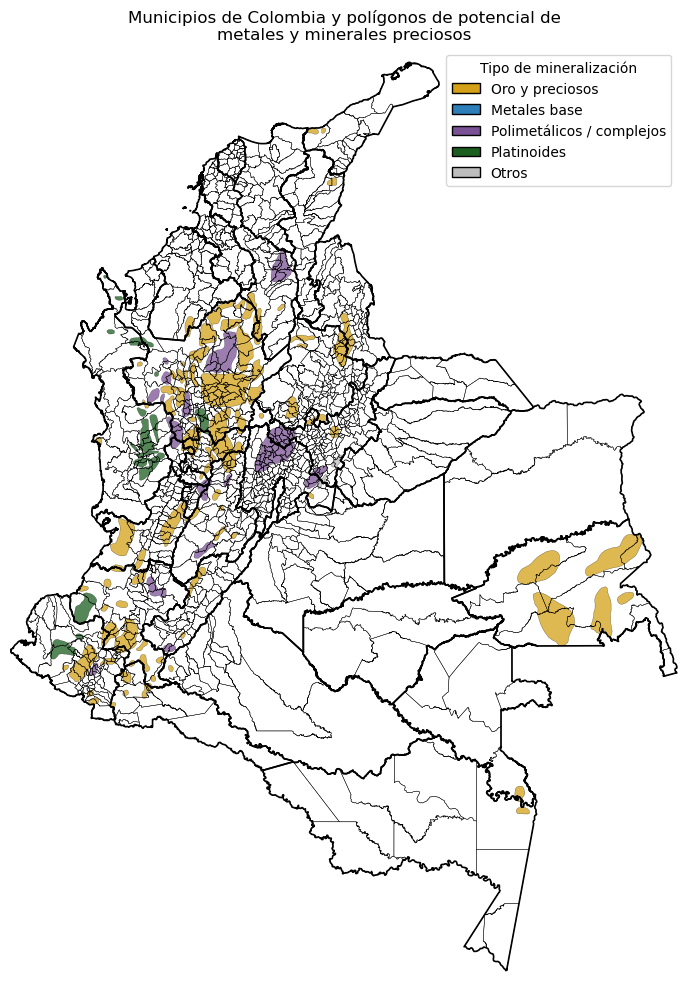

<Figure size 640x480 with 0 Axes>

In [15]:
# Elementos básicos de la gráfica
fig, ax = plt.subplots(figsize=(12, 12))

# Contornos de municipios y departamentos
gdf_municipios.boundary.plot(ax=ax, linewidth=0.3, color='black')
gdf_departamentos.boundary.plot(ax=ax, linewidth=1.2, color='black')

# Polígonos de potencial: relleno por categoría
#gdf_potencial.plot(ax=ax, linewidth=0.8, color='pink')
for categoria, color in colores_categoria.items():
    subset = gdf_potencial[gdf_potencial["categoria_mineral"] == categoria]
    if len(subset) > 0:
        subset.plot(
            ax=ax,
            color=color,
            edgecolor="black",
            linewidth=0.2,
            alpha=0.75
        )

# Leyenda manual
handles = [
    Patch(facecolor=color, edgecolor="black", label=cat)
    for cat, color in colores_categoria.items()
]

ax.legend(
    handles=handles,
    title="Tipo de mineralización",
    loc="upper right",
    frameon=True
)


# Ejes
ax.set_xlim([0.45e6, 1.81e6])
ax.set_ylim([0.02e6, 1.9e6])
ax.set_axis_off()

# Presentación de la gráfica
ax.set_title("Municipios de Colombia y polígonos de potencial de\nmetales y minerales preciosos")

# Mostrar y exportar gráfica
plt.show()
plt.tight_layout()
fig.savefig('./M1_municipios_poligonosPotencial.png', dpi=500)

## Mapa de porcentaje de area cubierta

In [16]:
# Unir datos de los municipios con el porcentaje de area cubierta
mapa_municipios = gdf_municipios.merge(
    resumen_municipio[["mpio_cdpmp", "pct_municipio_cubierto"]],
    on="mpio_cdpmp",
    how="left"
)

# Los municipios que no tiene area con potencial quedan con Nan. Cambiar por cero
mapa_municipios["pct_municipio_cubierto"] = mapa_municipios["pct_municipio_cubierto"].fillna(0)

# Crear escalas de colores para mostrar los datos de los municipios
# Crear columna donde los ceros sean NaN (para que salgan blancos)
mapa_municipios["pct_plot"] = mapa_municipios["pct_municipio_cubierto"].replace(0, np.nan)



In [1]:
# Elementos básicos de la gráfica
fig, ax = plt.subplots(figsize=(12, 12))

# Contornos de departamentos ----------------------------------------------
gdf_departamentos.boundary.plot(ax=ax, linewidth=1.2, color='black')

# Colorear los municipios según el porcentaje de area cubierto -------------
mapa_municipios.plot(
    column="pct_plot",
    cmap="YlOrRd",
    ax=ax,
    legend=False,
    linewidth=0.1,
    edgecolor="black",
    missing_kwds={ # Pintar Nans como blanco
        "color": "white",
        "label": "Sin potencial"
    }
)


# Crear barra de color horizontal ------------------------------------------
# Variables auxiliares para manejar la leyenda de los colores
# Definir normalización de colores
vmin = 0
vmax = mapa_municipios["pct_municipio_cubierto"].max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.YlOrRd

# Ubicar la barra de colores
cax = fig.add_axes([0.6, 0.65, 0.08, 0.1])
cax.set_axis_off()

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm._A = []  # necesario para matplotlib

cbar = fig.colorbar(
    sm,
    ax=cax,
    orientation="vertical",
    fraction=0.5
)
cbar.set_ticks([0, 25, 50, 75, 100]) # Ticks de la barra de colores

# Incluir anotación como leyenda de la barra de colores
ax.annotate(text="Porcentaje del\nárea municipal",
            xy=(0.74,0.85), xycoords='axes fraction',
            ha='center', va='bottom')


# Ejes -----------------------------------------------------------------------
ax.set_xlim([0.45e6, 1.81e6])
ax.set_ylim([0.02e6, 1.9e6])
ax.set_axis_off()

# Presentación de la gráfica --------------------------------------------------
ax.set_title("Porcentaje del municipio cubierto por polígonos de potencial de\nmetales y minerales preciosos")

# Mostrar y exportar gráfica
plt.show()
plt.tight_layout()
fig.savefig('./M2_municipios_porcentajeCubierto.png', dpi=500)

NameError: name 'plt' is not defined

# Exportar datos

In [18]:
# Exportar los datos de porcentaje del area del municipio con potencial minero
display(resumen_municipio.head())

# Exportar el porcenteaje del area municipal con potencial minero
ruta_salida_mapa_municipios = './porcentaje_area_municipal_potencial_minero'
mapa_municipios.to_parquet(ruta_salida_mapa_municipios + '.parquet')
mapa_municipios.to_excel(ruta_salida_mapa_municipios + '.xlsx')

# Exportar los poligonos de intersección identificando la categoría mineral
# Por si necesito explorar tendencias en diferentes tipos de minerales
ruta_salida_poligonos_interseccion = './poligonos_interseccion_por_categoriaMineral'
gdf_interseccion.to_parquet(ruta_salida_poligonos_interseccion + '.parquet')
gdf_interseccion.to_excel(ruta_salida_poligonos_interseccion + '.xlsx')

,mpio_cdpmp,mpio_cnmbr,area_potencial_m2,area_municipio_m2,pct_municipio_cubierto
0,05002,ABEJORRAL,4.514032e+08,5.071411e+08,89.009394
1,05004,ABRIAQUÍ,1.711970e+08,2.969560e+08,57.650626
2,05021,ALEJANDRÍA,1.289322e+08,1.289322e+08,100.000000
3,05030,AMAGÁ,2.603725e+07,8.413248e+07,30.947918
4,05031,AMALFI,7.983211e+08,1.209145e+09,66.023576
